In [1]:
# Step 1: Install required packages
!pip install ultralytics opencv-python pyyaml

# Step 2: Import libraries
import cv2
import numpy as np
from ultralytics import YOLO
from collections import defaultdict, deque
from google.colab.patches import cv2_imshow
import urllib.request
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
# Step 3: Download your code (I'll recreate it here for Colab)
class StreetSceneAnalyzer:
    def __init__(self):
        # Load YOLO model
        self.model = YOLO('yolov8n.pt')

        # Store previous frame data for motion detection
        self.previous_positions = defaultdict(lambda: deque(maxlen=10))

        # Colors for different states
        self.colors = {
            'moving': (0, 255, 0),      # Green
            'stopped': (0, 0, 255),     # Red
            'unknown': (255, 255, 255), # White
            'red_light': (0, 0, 255),
            'green_light': (0, 255, 0),
            'yellow_light': (0, 255, 255)
        }

    def detect_traffic_light_color(self, frame, bbox):
        """Detect traffic light color within bounding box"""
        x1, y1, x2, y2 = map(int, bbox)
        traffic_light_roi = frame[y1:y2, x1:x2]

        if traffic_light_roi.size == 0:
            return "unknown", self.colors['unknown']

        # Convert to HSV for better color detection
        hsv = cv2.cvtColor(traffic_light_roi, cv2.COLOR_BGR2HSV)

        # Define color ranges in HSV
        red_lower1 = np.array([0, 120, 70])
        red_upper1 = np.array([10, 255, 255])
        red_lower2 = np.array([170, 120, 70])
        red_upper2 = np.array([180, 255, 255])

        green_lower = np.array([40, 40, 40])
        green_upper = np.array([90, 255, 255])

        yellow_lower = np.array([20, 100, 100])
        yellow_upper = np.array([30, 255, 255])

        # Create masks for each color
        red_mask1 = cv2.inRange(hsv, red_lower1, red_upper1)
        red_mask2 = cv2.inRange(hsv, red_lower2, red_upper2)
        red_mask = red_mask1 + red_mask2

        green_mask = cv2.inRange(hsv, green_lower, green_upper)
        yellow_mask = cv2.inRange(hsv, yellow_lower, yellow_upper)

        # Count colored pixels
        red_pixels = cv2.countNonZero(red_mask)
        green_pixels = cv2.countNonZero(green_mask)
        yellow_pixels = cv2.countNonZero(yellow_mask)

        # Determine dominant color
        max_pixels = max(red_pixels, green_pixels, yellow_pixels)

        if max_pixels < 10:
            return "unknown", self.colors['unknown']
        elif red_pixels == max_pixels:
            return "red", self.colors['red_light']
        elif green_pixels == max_pixels:
            return "green", self.colors['green_light']
        elif yellow_pixels == max_pixels:
            return "yellow", self.colors['yellow_light']
        else:
            return "unknown", self.colors['unknown']

    def calculate_movement(self, current_bbox, track_id, object_type):
        """Calculate if object is moving or stopped"""
        current_center = np.array([
            (current_bbox[0] + current_bbox[2]) / 2,
            (current_bbox[1] + current_bbox[3]) / 2
        ])

        # Store current position
        self.previous_positions[track_id].append(current_center)

        if len(self.previous_positions[track_id]) < 2:
            return "analyzing", self.colors['unknown']

        # Calculate total distance moved
        total_distance = 0
        positions = list(self.previous_positions[track_id])

        for i in range(1, len(positions)):
            distance = np.linalg.norm(positions[i] - positions[i-1])
            total_distance += distance

        # Movement thresholds
        if object_type == "person":
            movement_threshold = 3.0
        else:
            movement_threshold = 2.0

        if total_distance > movement_threshold:
            return "moving", self.colors['moving']
        else:
            return "stopped", self.colors['stopped']

    def process_frame(self, frame):
        """Process each frame for street scene analysis"""
        results = self.model.track(frame, persist=True, verbose=False)

        analyzed_objects = []
        traffic_lights = []

        for result in results:
            if result.boxes is not None and result.boxes.id is not None:
                for box, track_id in zip(result.boxes, result.boxes.id):
                    class_id = int(box.cls[0])
                    label = self.model.names[class_id]
                    confidence = float(box.conf[0])
                    bbox = box.xyxy[0].cpu().numpy()
                    track_id = int(track_id.cpu().numpy())

                    if confidence > 0.5:
                        object_info = {
                            'label': label,
                            'bbox': bbox,
                            'track_id': track_id,
                            'confidence': confidence
                        }

                        # Traffic light analysis
                        if label == 'traffic light':
                            color, color_rgb = self.detect_traffic_light_color(frame, bbox)
                            object_info.update({
                                'type': 'traffic_light',
                                'color': color,
                                'display_color': color_rgb
                            })
                            traffic_lights.append(object_info)

                        # Person/vehicle movement analysis
                        elif label in ['person', 'car', 'truck', 'bus', 'motorcycle', 'bicycle']:
                            movement, movement_color = self.calculate_movement(bbox, track_id, label)
                            object_info.update({
                                'type': 'moving_object',
                                'movement': movement,
                                'display_color': movement_color
                            })
                            analyzed_objects.append(object_info)

        return analyzed_objects, traffic_lights

    def draw_analysis(self, frame, objects, traffic_lights):
        """Draw bounding boxes and analysis information"""
        # Draw moving objects
        for obj in objects:
            x1, y1, x2, y2 = map(int, obj['bbox'])
            color = obj['display_color']

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            if obj['type'] == 'moving_object':
                label = f"{obj['label']} - {obj['movement']}"
            else:
                label = f"{obj['label']}"

            label_text = f"{label} ({obj['confidence']:.2f})"
            label_size = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)[0]

            cv2.rectangle(frame, (x1, y1 - label_size[1] - 10),
                         (x1 + label_size[0], y1), color, -1)
            cv2.putText(frame, label_text, (x1, y1 - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

        # Draw traffic lights
        for tl in traffic_lights:
            x1, y1, x2, y2 = map(int, tl['bbox'])
            color = tl['display_color']

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
            circle_center = (x1 + 20, y1 - 20)
            cv2.circle(frame, circle_center, 10, color, -1)
            cv2.circle(frame, circle_center, 10, (255, 255, 255), 2)

            label_text = f"traffic light - {tl['color']}"
            cv2.putText(frame, label_text, (x1, y1 - 25),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

        return frame

📁 Please upload a video file...


Saving Untitled design.mp4 to Untitled design.mp4
✓ Uploaded: Untitled design.mp4


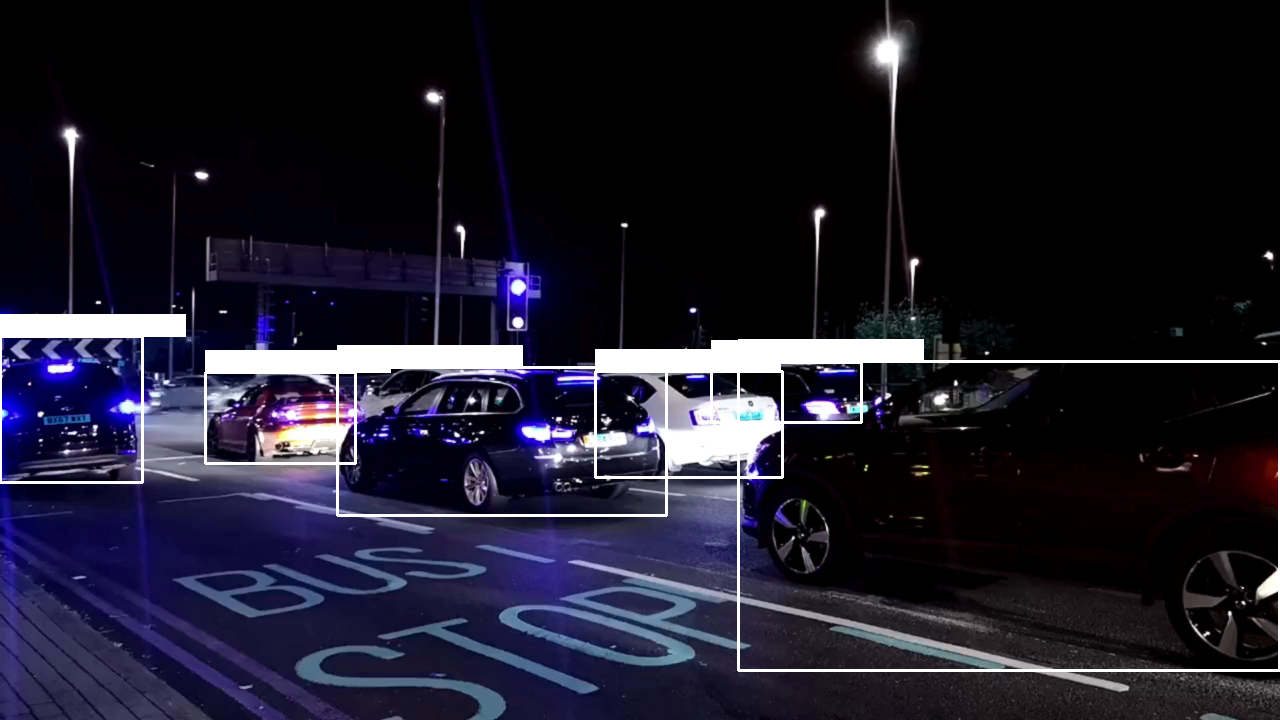

Frame 0: Moving: 0, Stopped: 0


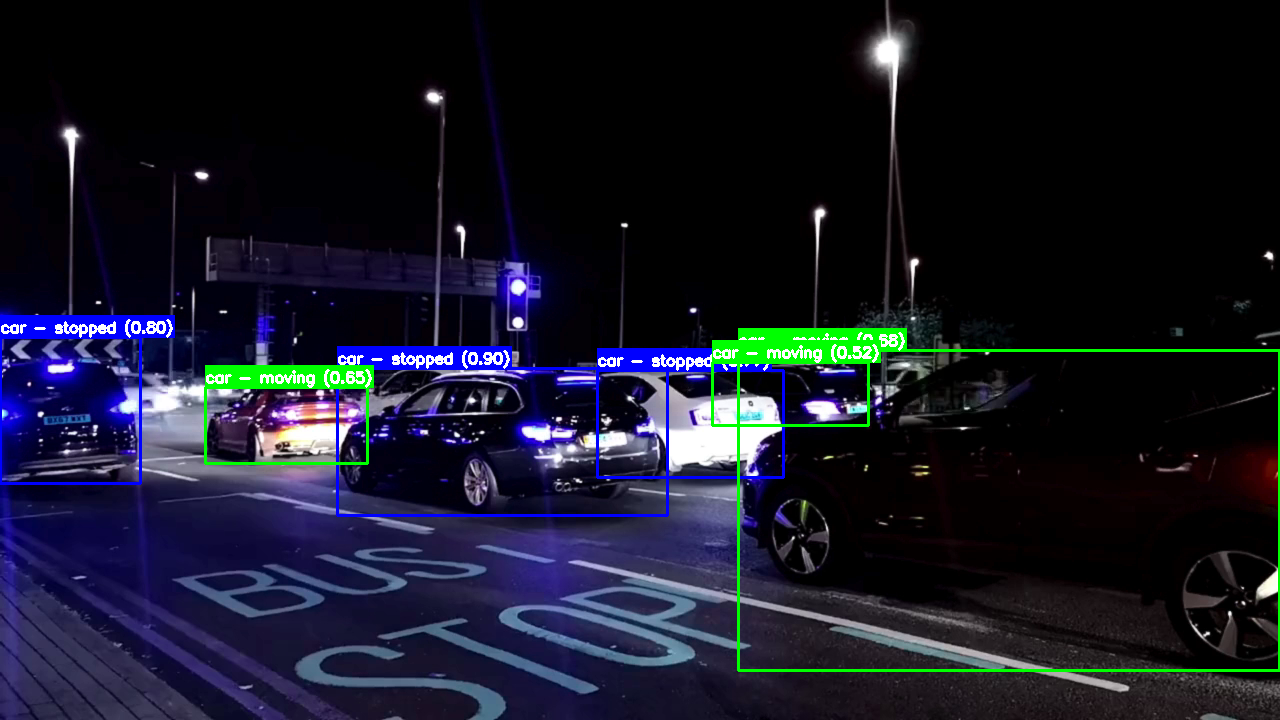

Frame 5: Moving: 3, Stopped: 3


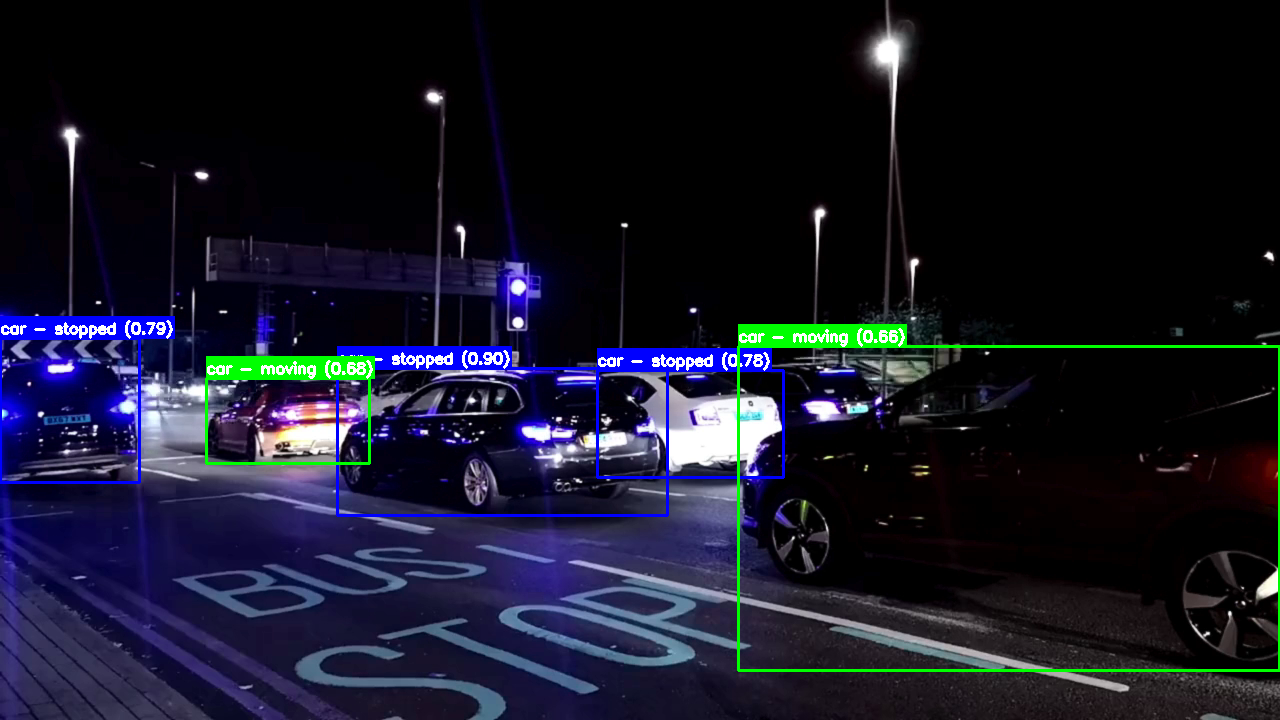

Frame 10: Moving: 2, Stopped: 3


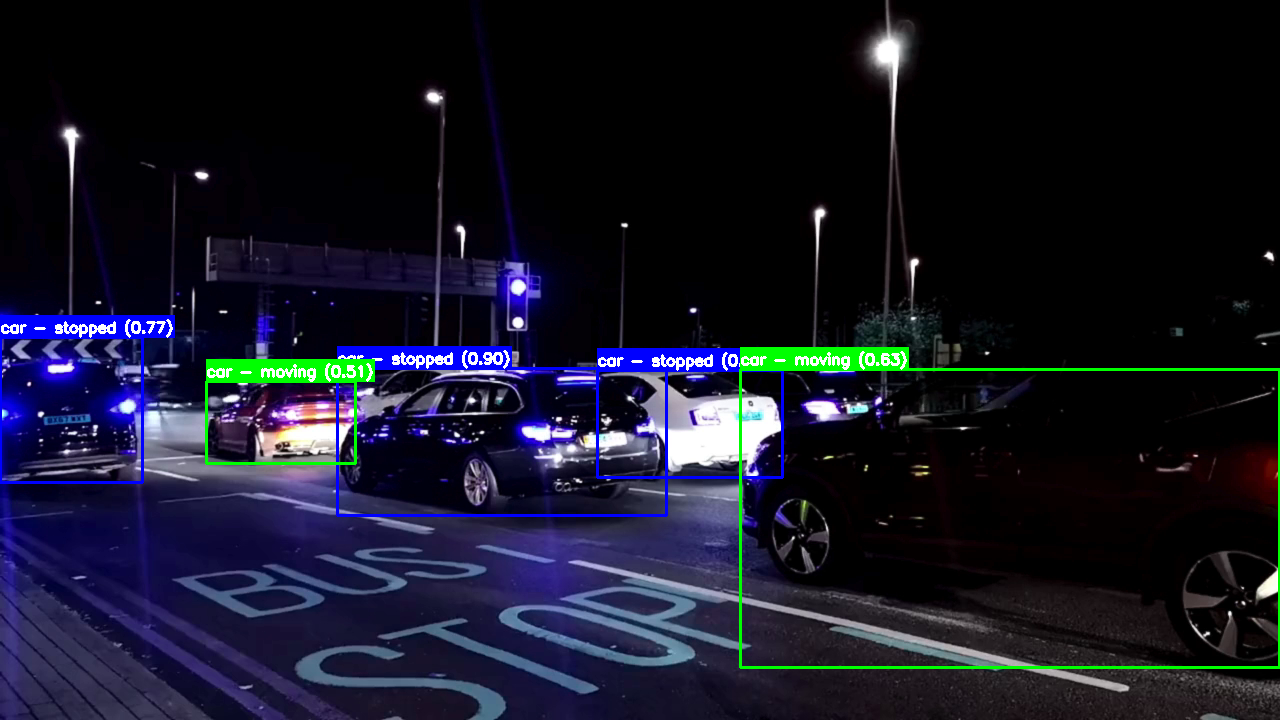

Frame 15: Moving: 2, Stopped: 3


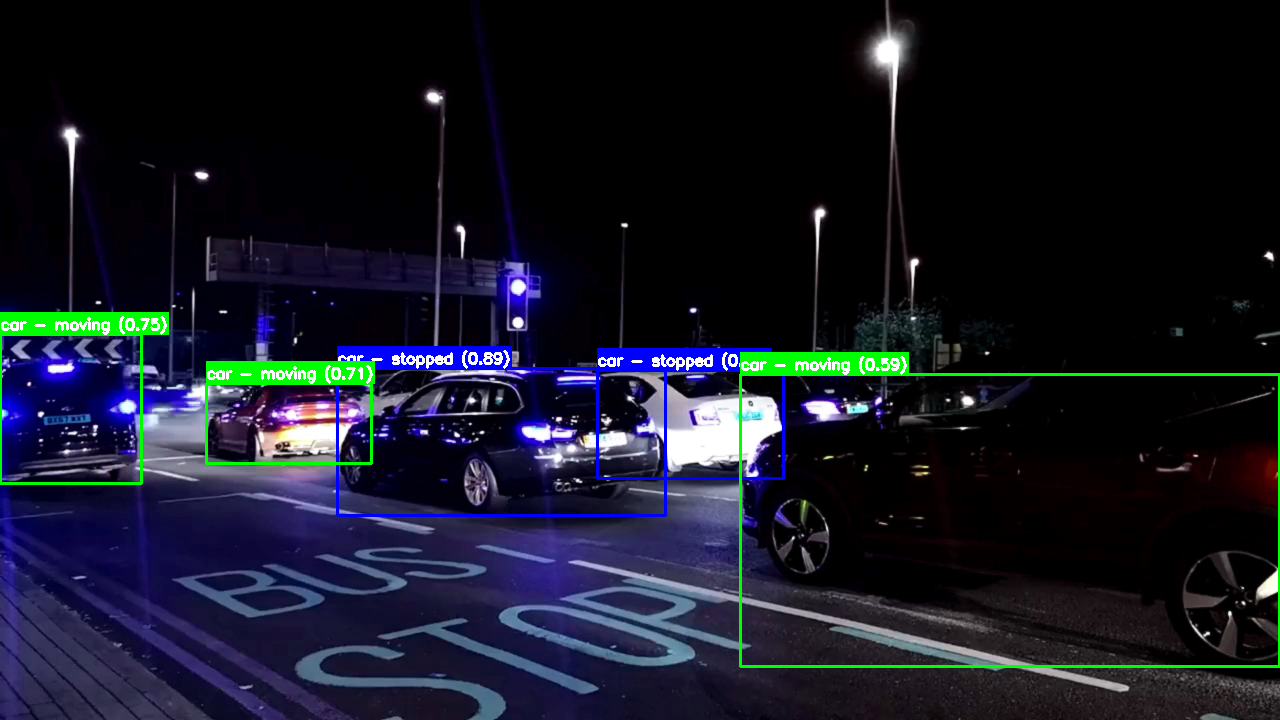

Frame 20: Moving: 3, Stopped: 2


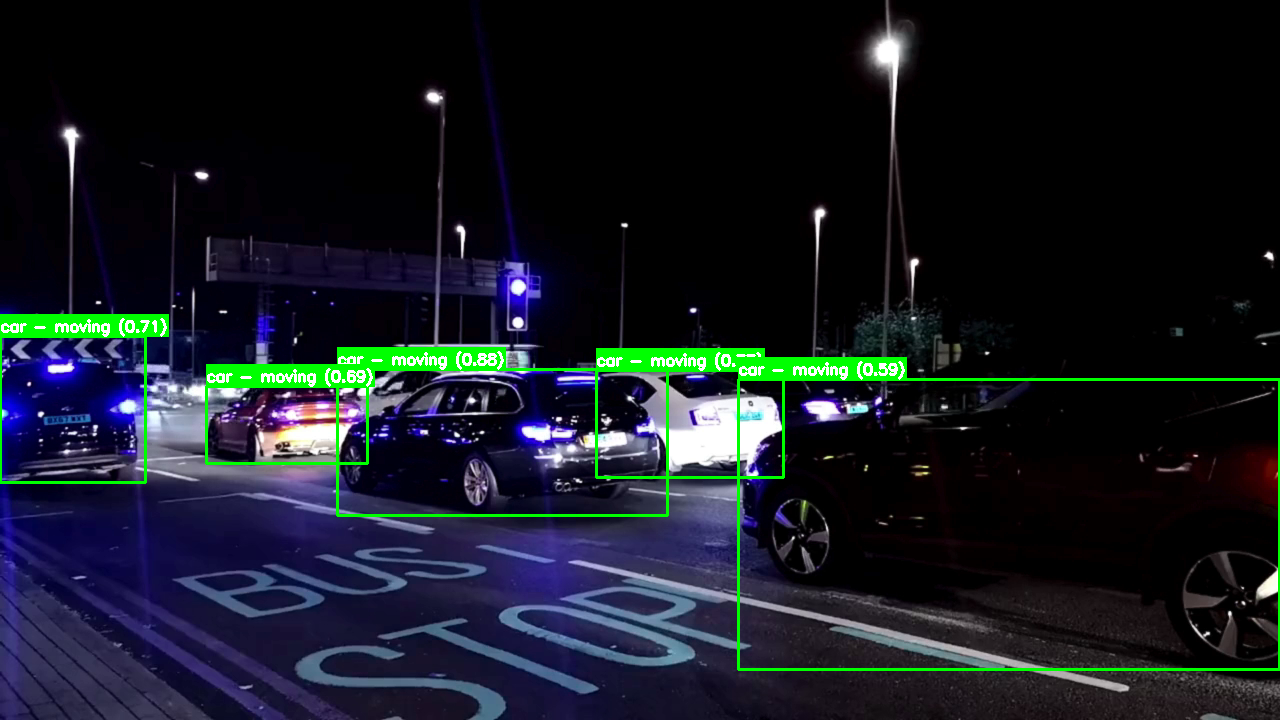

Frame 25: Moving: 5, Stopped: 0
✅ Analysis completed!


In [11]:
from google.colab import files
import os

def create_synthetic_video():
    """Create a simple synthetic video for testing"""
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter('synthetic_test.mp4', fourcc, 20.0, (640, 480))

    for i in range(100):  # 100 frames
        # Create a blank frame
        frame = np.zeros((480, 640, 3), dtype=np.uint8)

        # Add some moving objects
        cv2.rectangle(frame, (50 + i, 100), (150 + i, 200), (0, 255, 0), -1)  # Moving car
        cv2.rectangle(frame, (300, 200 - i//2), (400, 300 - i//2), (255, 0, 0), -1)  # Moving person
        cv2.rectangle(frame, (500, 150), (550, 200), (0, 0, 255), -1)  # Static traffic light

        # Add text labels
        cv2.putText(frame, f"Frame {i}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
        cv2.putText(frame, "Moving Car", (50 + i, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(frame, "Moving Person", (300, 190 - i//2), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        out.write(frame)

    out.release()
    print("✓ Synthetic test video created: synthetic_test.mp4")

def upload_and_analyze():
    print("📁 Please upload a video file...")
    uploaded = files.upload()

    if uploaded:
        video_file = list(uploaded.keys())[0]
        print(f"✓ Uploaded: {video_file}")

        analyzer = StreetSceneAnalyzer()
        cap = cv2.VideoCapture(video_file)

        frame_count = 0
        while frame_count < 30:  # Process first 30 frames
            ret, frame = cap.read()
            if not ret:
                break

            objects, traffic_lights = analyzer.process_frame(frame)
            frame = analyzer.draw_analysis(frame, objects, traffic_lights)

            # Display every 5th frame
            if frame_count % 5 == 0:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                cv2_imshow(frame_rgb)

                moving_count = len([obj for obj in objects if obj.get('movement') == 'moving'])
                stopped_count = len([obj for obj in objects if obj.get('movement') == 'stopped'])
                print(f"Frame {frame_count}: Moving: {moving_count}, Stopped: {stopped_count}")

            frame_count += 1

        cap.release()
        print("✅ Analysis completed!")
    else:
        print("❌ No file uploaded. Using synthetic video...")
        create_synthetic_video()
        analyze_video("synthetic_test.mp4")

# Uncomment the line below to use upload
upload_and_analyze()

In [17]:
# Step 5 Alternative: Process entire uploaded video
def analyze_full_video():
    print("📁 Upload your video for complete analysis...")
    uploaded = files.upload()

    if uploaded:
        video_file = list(uploaded.keys())[0]
        print(f"✅ Analyzing: {video_file}")

        analyzer = StreetSceneAnalyzer()
        cap = cv2.VideoCapture(video_file)

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        print(f"🎯 Processing all {total_frames} frames...")

        frame_count = 0
        results = []

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            objects, traffic_lights = analyzer.process_frame(frame)
            results.append({
                'frame': frame_count,
                'objects': objects,
                'traffic_lights': traffic_lights
            })

            # Show progress every 50 frames
            if frame_count % 50 == 0:
                moving = len([obj for obj in objects if obj.get('movement') == 'moving'])
                stopped = len([obj for obj in objects if obj.get('movement') == 'stopped'])
                print(f"   Frame {frame_count}: {moving} moving, {stopped} stopped")

            frame_count += 1

        cap.release()
        print(f"✅ Complete! Processed {frame_count} frames")
        return results
    else:
        print("❌ No file uploaded")
        return None

# Uncomment below to process entire video:
analyze_full_video()

📁 Upload your video for complete analysis...


Saving Untitled design.mp4 to Untitled design (1).mp4
✅ Analyzing: Untitled design (1).mp4
🎯 Processing all 744 frames...
   Frame 0: 0 moving, 0 stopped
   Frame 50: 3 moving, 2 stopped
   Frame 100: 2 moving, 0 stopped
   Frame 150: 1 moving, 1 stopped
   Frame 200: 1 moving, 0 stopped
   Frame 250: 1 moving, 0 stopped
   Frame 300: 1 moving, 0 stopped
   Frame 350: 1 moving, 3 stopped
   Frame 400: 1 moving, 1 stopped
   Frame 450: 3 moving, 1 stopped
   Frame 500: 5 moving, 2 stopped
   Frame 550: 4 moving, 0 stopped
   Frame 600: 2 moving, 0 stopped
   Frame 650: 1 moving, 2 stopped
   Frame 700: 2 moving, 0 stopped
✅ Complete! Processed 744 frames


[{'frame': 0,
  'objects': [{'label': 'car',
    'bbox': array([     337.55,      367.71,      666.57,       515.1], dtype=float32),
    'track_id': 1,
    'confidence': 0.8952417969703674,
    'type': 'moving_object',
    'movement': 'analyzing',
    'display_color': (255, 255, 255)},
   {'label': 'car',
    'bbox': array([   0.044647,      336.42,      142.58,      482.93], dtype=float32),
    'track_id': 2,
    'confidence': 0.786573052406311,
    'type': 'moving_object',
    'movement': 'analyzing',
    'display_color': (255, 255, 255)},
   {'label': 'car',
    'bbox': array([     205.18,      372.36,      355.91,      463.76], dtype=float32),
    'track_id': 3,
    'confidence': 0.7514041662216187,
    'type': 'moving_object',
    'movement': 'analyzing',
    'display_color': (255, 255, 255)},
   {'label': 'car',
    'bbox': array([     595.75,      371.08,      782.89,      477.83], dtype=float32),
    'track_id': 4,
    'confidence': 0.7470629215240479,
    'type': 'moving_objec